## Projet - Segmentation  avec MedSAM2.

MedSAM est une version spécialisée du Segment Anything Model (SAM2), entraînée sur des milliers d'images médicales. Il permet une segmentation en Zero-Shot : sans réentraînement spécifique, il peut délimiter une structure basée sur une simple prompt (point cliqué, bounding box).

Objectif : Évaluer la performance (Dice Score, le Jaccard Index (IoU)) de MedSAM pour la segmentation de tumeur cérébrale .

git clone https://github.com/bowang-lab/MedSAM2.git
cd MedSAM2
pip install -e .

In [1]:
import torch
import os
import numpy as np
from utils import MRIPreprocessingImage, MedSamMetrics, MetricsLivePlot
import random 
import matplotlib.pyplot as plt

In [ ]:
random.seed(42)
data_dir = "D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/" 
files_npz = os.listdir(data_dir)
files_npz = [f for f in files_npz if f.endswith(".npz")]
idx_rd = np.random.randint(len(files_npz)) #48, 37
data = np.load(os.path.join(data_dir, files_npz[idx_rd]))

print("Image shape:", data['seg'].shape)
print("Volume tumoral:", data["volume"])

Image shape: (240, 240, 155)
Volume tumoral: 204242


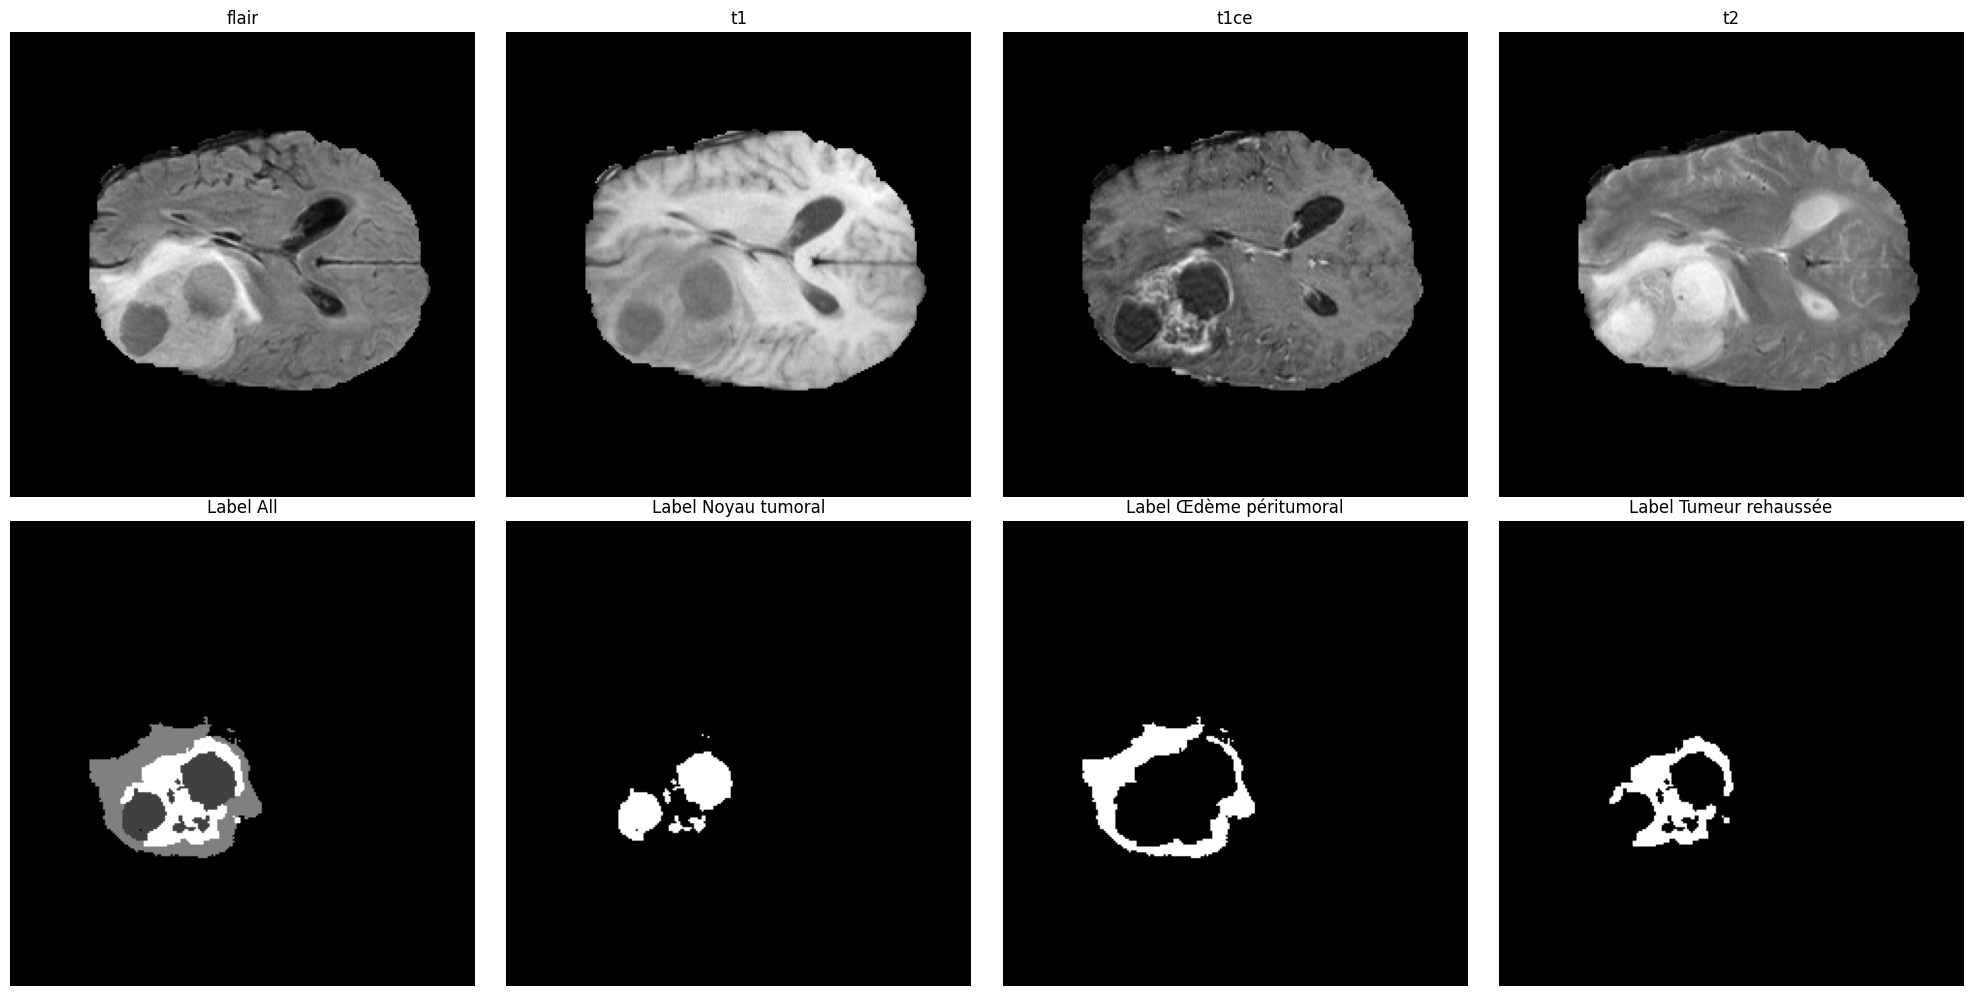

In [11]:
mask_name ={0: 'All', 1:'Noyau tumoral', 2: 'Œdème péritumoral', 4:'Tumeur rehaussée'}
# Modalités (tout sauf volume et seg)
modalities = [k for k in data.files if k not in ['volume', 'seg']]
labels = [0, 1, 2, 4]
total = len(modalities) + len(labels)
cols = int(np.ceil(total / 2))
rows = 2
plt.figure(figsize=(5 * cols, 10))
i = 1

# --- Affichage des modalités ---
for key in modalities:
    plt.subplot(rows, cols, i)
    plt.imshow(data[key][:, :, 77], cmap='gray')
    plt.title(key)
    plt.axis("off")
    i += 1

# --- Affichage des labels ---
for j in labels:
    plt.subplot(rows, cols, i)
    if j > 0:
        plt.imshow(data['seg'][:, :, 77] == j, cmap='gray')
    else:
        plt.imshow(data['seg'][:, :, 77], cmap='gray')
    plt.title(f"Label {mask_name[j]}")
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

In [4]:
from segment_anything import SamPredictor, sam_model_registry

MODEL_TYPE = "vit_b"
CHECKPOINT_PATH = "D:/marchine_learning/Projet/Segmentation/MedSam/model/medsam_vit_b.pth"
DEVICE = "cpu"
print(f"Chargement de MedSAM sur : {DEVICE}")
if os.path.exists(CHECKPOINT_PATH):

    sam = sam_model_registry[MODEL_TYPE]()
    state_dict = torch.load(CHECKPOINT_PATH, map_location=torch.device("cpu"))

    # 3. Appliquer les poids
    sam.load_state_dict(state_dict)
    sam.to(device=DEVICE)
    sam.eval()

    # 5. Créer le prédicteur
    predictor = SamPredictor(sam)
else:
    print('Techarger le poit du model sur https://github.com/bowang-lab/MedSAM?tab=readme-ov-file')
    
# if image is load clear it
def clear_image(predictor, verbose = 0):
    if predictor.is_image_set:
        predictor.reset_image()
        if verbose > 0:
            print(predictor.is_image_set)

Chargement de MedSAM sur : cpu


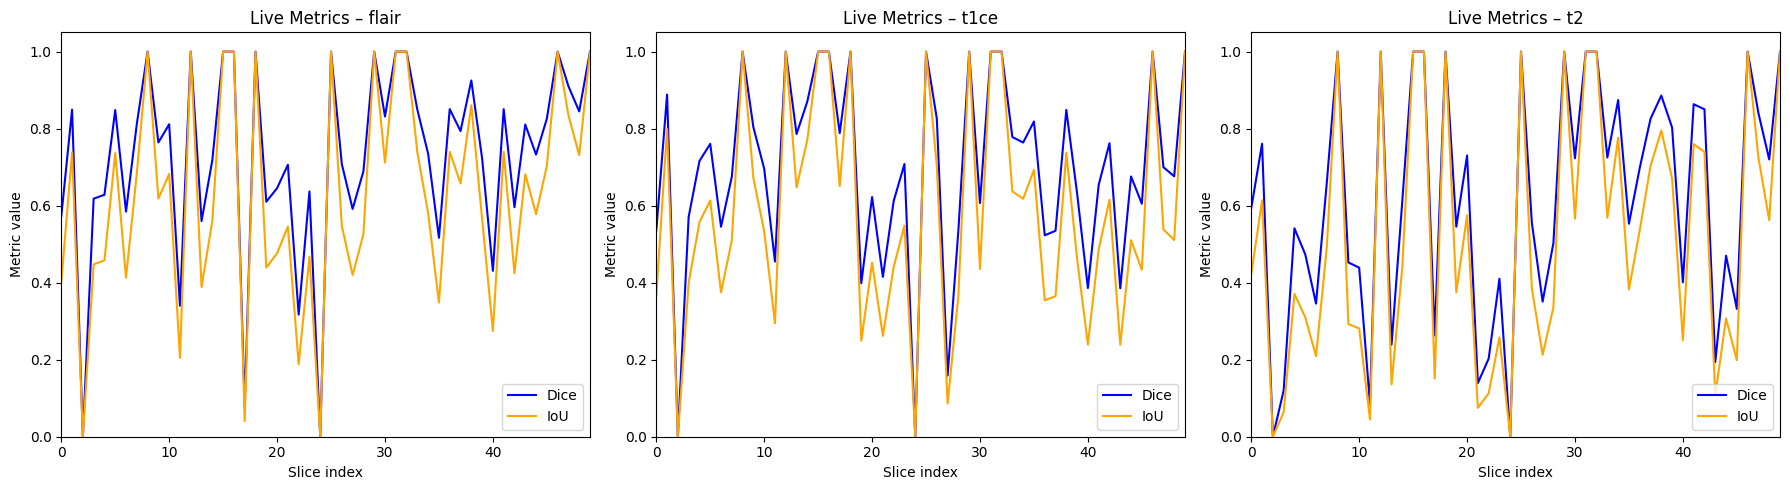

Scores moyens Dice : {'flair': np.float64(0.7262611015829412), 't1ce': np.float64(0.6943322934425408), 't2': np.float64(0.6156605659841451)}
Scores moyens IoU  : {'flair': np.float64(0.6230567497511246), 't1ce': np.float64(0.5833603655512879), 't2': np.float64(0.5161704117017674)}


In [13]:
modalities = ["flair", "t1ce", "t2"]
results_dice = {m: [] for m in modalities}
results_iou  = {m: [] for m in modalities}
results  = {m: [] for m in modalities}
liveplot = MetricsLivePlot(modalities)

for modality in modalities:
    for j, file_npz in enumerate(files_npz):

        data = np.load(os.path.join(data_dir, file_npz))
        img_slice = data[modality][:, :, 77] 
        mask_slice = data['seg'][:, :, 77] 

        # Définir box prompt meilleur resultat que les points
        white_rows, white_cols = np.where(mask_slice.astype(bool))
        if len(white_rows) == 0: 
            input_box = None
        else:
            x_min, y_min = min(white_cols), min(white_rows)
            x_max, y_max = max(white_cols), max(white_rows)
            input_box = np.array([(x_min, y_min), (x_max, y_max)])

        # Tranform en RGB pour SAM
        img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min()) * 255.0
        img_uint8 = img_slice.astype(np.uint8)
        image_rgb = np.repeat(img_uint8[:, :, np.newaxis], 3, axis=-1)

        clear_image(predictor)
        predictor.set_image(image_rgb)

        # Inférence SAM (CPU lent)
        masks_sam, scores, logits = predictor.predict(
            box=input_box,
            multimask_output=True,
        )

        metrics = MedSamMetrics(img_slice, mask_slice, masks_sam, scores)

        # Calcul métriques
        dice = metrics.dice()
        jacal = metrics.iou()
        liveplot.update(modality, j, dice, jacal)

        # Save metrics
        results_dice[modality].append(dice)
        results_iou[modality].append(jacal)
        results[modality].append(metrics)
    
# --- Moyenne des scores ---
avg_dice = {mod: np.mean(results_dice[mod]) for mod in modalities}
avg_iou  = {mod: np.mean(results_iou[mod]) for mod in modalities}

print("Scores moyens Dice :", avg_dice)
print("Scores moyens IoU  :", avg_iou)

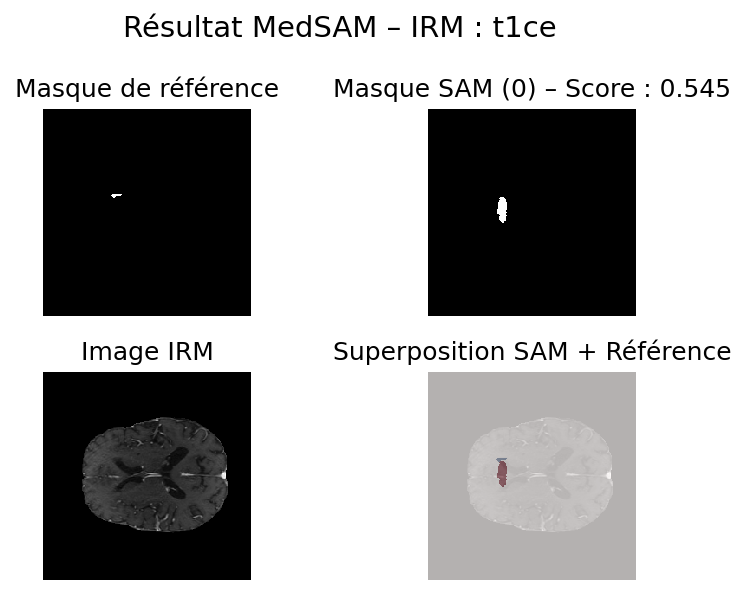

In [19]:
results["t1ce"][2].plot_masks(modality="t1ce")

In [ ]:
from skimage.morphology import closing, opening, ellipse, disk
from skimage.morphology import remove_small_objects 

flair = data['flair'][:, :, 62]
mask = data['seg'][:, :, 62]

def intensity_range(slice_ref, mask_ref, p_min=10, p_max=90):
    tumor_pixels = slice_ref[mask_ref > 0]
    return (
        np.percentile(tumor_pixels, p_min),
        np.percentile(tumor_pixels, p_max)
    )

def propagate(slice_curr, ref_inst, size_close=7):
    appearance = (slice_curr >= ref_inst[0]) & (slice_curr <= ref_inst[1])
    search_area = closing(appearance, footprint=disk(size_close))
    #mask_clean = opening(search_area, footprint=disk(3))
    mask_clean = remove_small_objects(search_area, min_size=30)
    return mask_clean

#La fenêtre s’adapte à la taille de la tumeur
#radius = int(np.sqrt(np.sum(prev_mask)))
#search_area = binary_dilation(prev_mask, iterations=radius//50 + 1)

In [85]:
threshold = intensity_range(flair, mask)

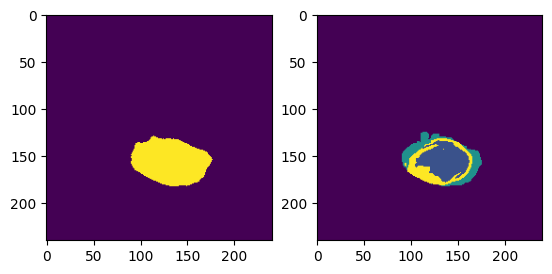

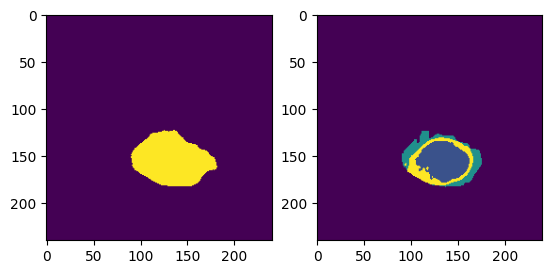

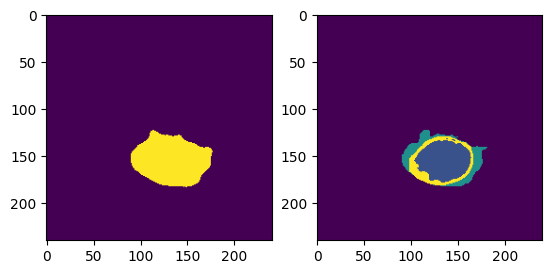

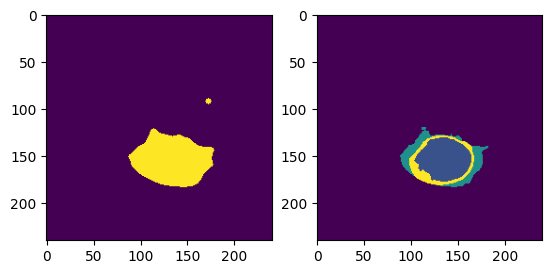

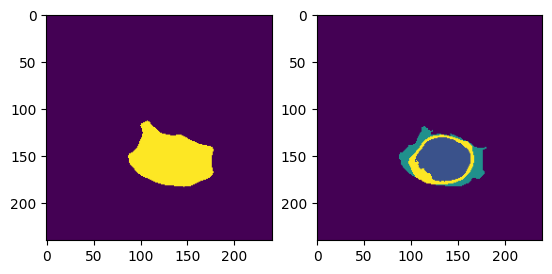

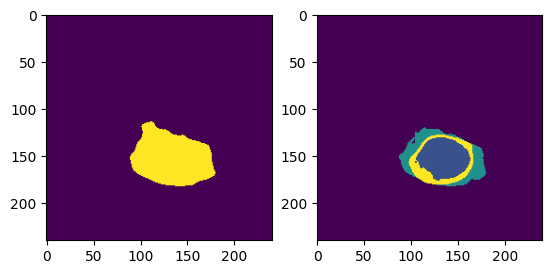

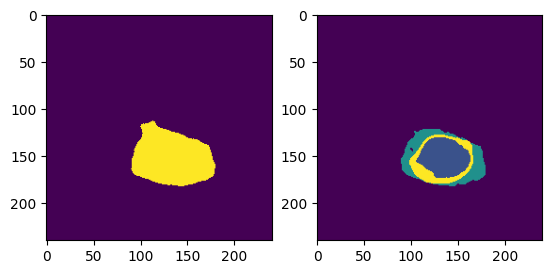

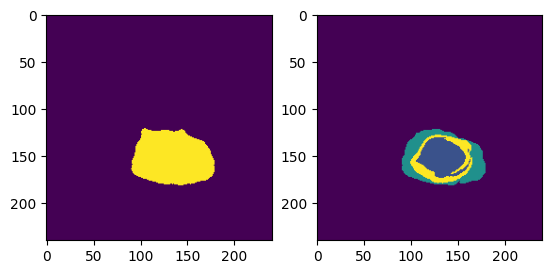

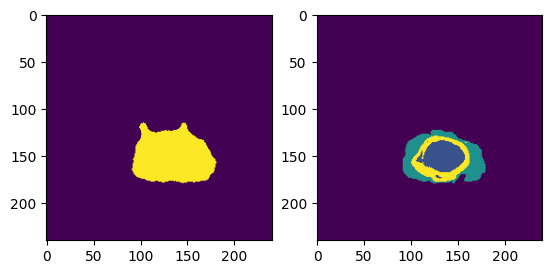

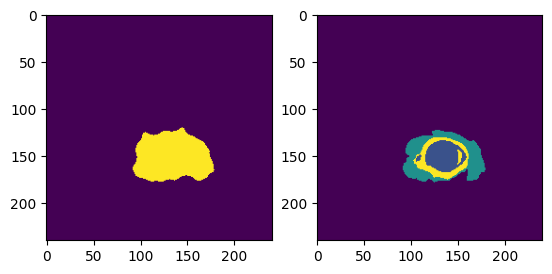

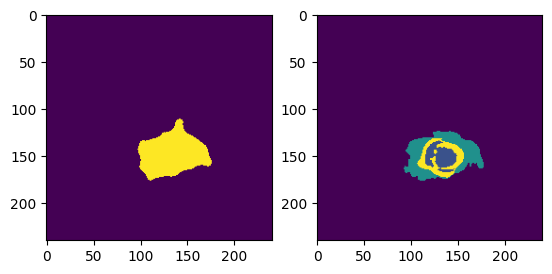

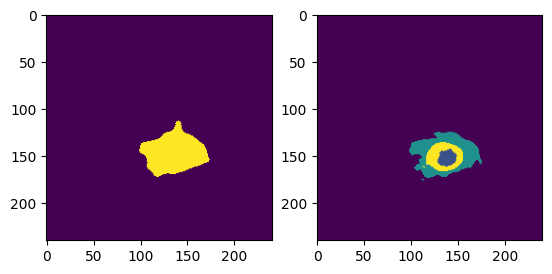

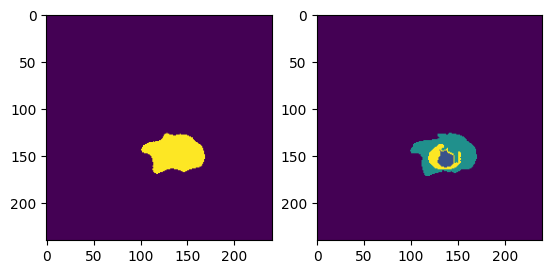

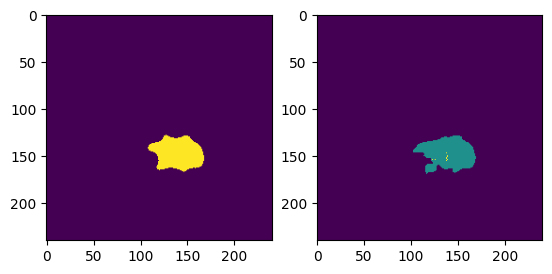

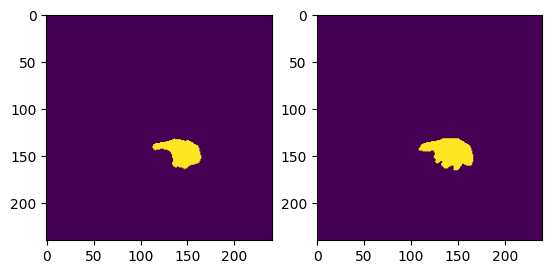

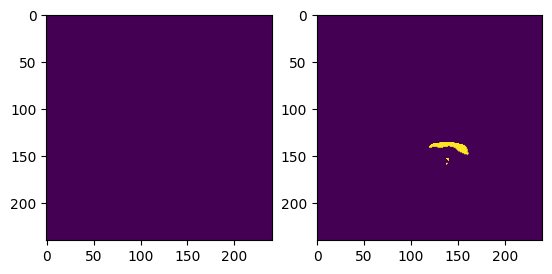

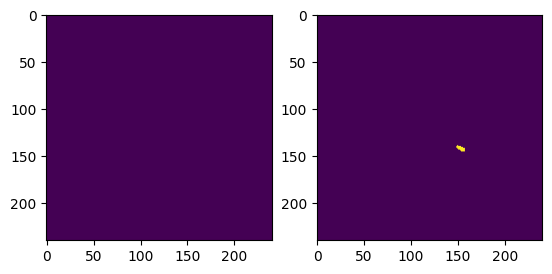

In [86]:
for i in range(50, 100, 3):
    flair = data['flair'][:, :, i]
    mask = data['seg'][:, :, i]
    mask_clean = propagate(flair, threshold, 10)
    plt.subplot(1,2, 1)
    plt.imshow(mask_clean)
    plt.subplot(1,2, 2)
    plt.imshow(mask)
    plt.show()

In [ ]:
import torch

from medsam2 import MedSAM2  # à adapter selon le repo réel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MedSAM2(
    backbone="vit_b",         # ou autre
    checkpoint="medsam2_ckpt.pth"
)
model.to(device)
model.eval()


In [ ]:
from medsam2 import MedSAM2
import torch
import nibabel as nib

# Charger modèle
model = MedSAM2.from_pretrained("checkpoints/medsam2_vit_b.pth")
model.eval().cuda()

# Charger volume
nii = nib.load("scan.nii.gz")
volume = nii.get_fdata()  # shape (H, W, D)

# Charger volume NPZ 
volume = np.load("scan.npz")["volume"]

# Normalisation
volume = (volume - volume.min()) / (volume.max() - volume.min())

# Convertir en tensor
vol_tensor = torch.from_numpy(volume).float().unsqueeze(0).unsqueeze(0).cuda()  # (1,1,H,W,D)

# Inférence 3D
with torch.no_grad():
    mask_3d = model.predict_volume(vol_tensor)  # shape (1,1,H,W,D)


In [ ]:
with torch.no_grad():
    outputs = model(
        image=img_tensor,
        point_coords=points_tensor,
        point_labels=labels_tensor
    )
    # outputs["masks"] : (B, num_masks, H, W)
    pred_mask = outputs["masks"][0, 0]     # (H, W)
    pred_mask = (pred_mask > 0.5).float()


In [ ]:
pred_mask_np = pred_mask.cpu().numpy()
pred_mask_np = cv2.resize(pred_mask_np, (orig_size[1], orig_size[0]), interpolation=cv2.INTER_NEAREST)
pred_mask_np = (pred_mask_np > 0.5).astype(np.uint8)

In [5]:
from segment_anything import SamPredictor, sam_model_registry

MODEL_TYPE = "vit_b"
CHECKPOINT_PATH = "D:/marchine_learning/Projet/Segmentation/MedSam/model/medsam_vit_b.pth"
DEVICE = "cpu"
print(f"Chargement de MedSAM sur : {DEVICE}")
if os.path.exists(CHECKPOINT_PATH):

    sam = sam_model_registry[MODEL_TYPE]()
    state_dict = torch.load(CHECKPOINT_PATH, map_location=torch.device("cpu"))

    # 3. Appliquer les poids
    sam.load_state_dict(state_dict)
    sam.to(device=DEVICE)
    sam.eval()

    # 5. Créer le prédicteur
    predictor = SamPredictor(sam)
else:
    print('Techarger le poit du model sur https://github.com/bowang-lab/MedSAM?tab=readme-ov-file')
    
# if image is load clear it
def clear_image(predictor, verbose = 0):
    if predictor.is_image_set:
        predictor.reset_image()
        if verbose > 0:
            print(predictor.is_image_set)

Chargement de MedSAM sur : cpu


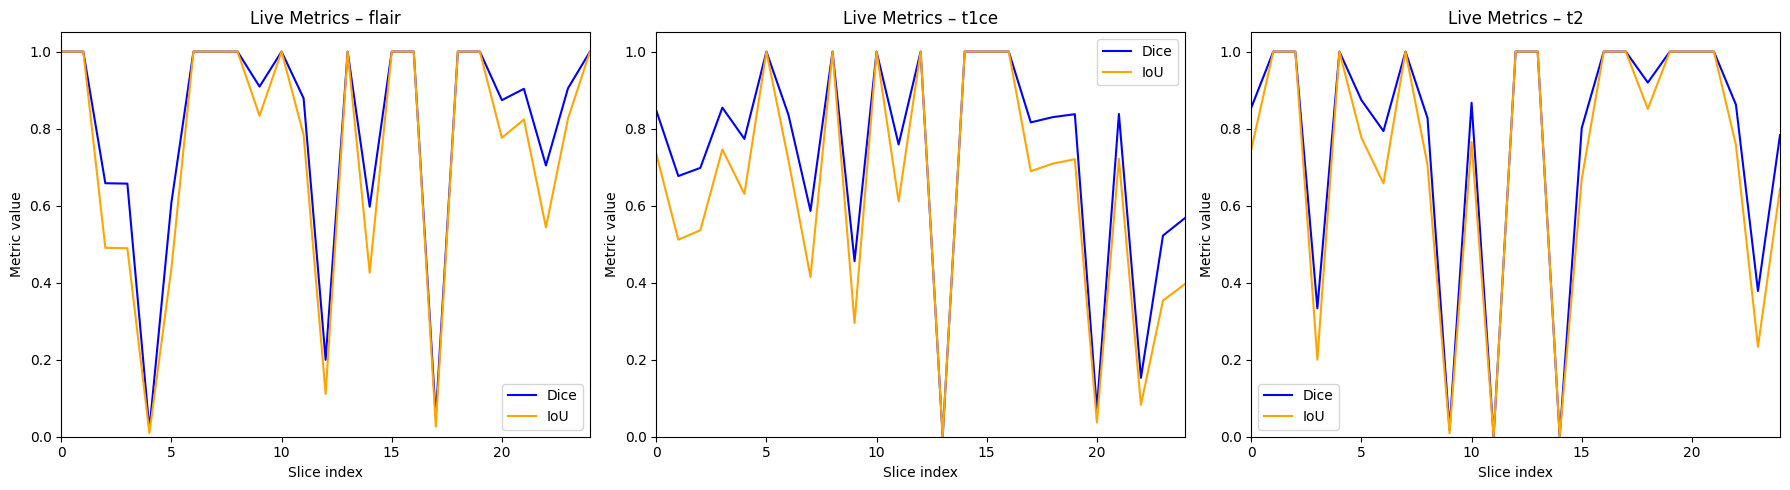

Scores moyens Dice : {'flair': np.float64(0.7985822753870911), 't1ce': np.float64(0.7248896310559028), 't2': np.float64(0.7725127337875378)}
Scores moyens IoU  : {'flair': np.float64(0.7430339177777617), 't1ce': np.float64(0.6363122757952105), 't2': np.float64(0.7205873725855967)}


In [ ]:
modalities = ["flair", "t1ce", "t2"]
results_dice = {m: [] for m in modalities}
results_iou  = {m: [] for m in modalities}
results  = {m: [] for m in modalities}
liveplot = MetricsLivePlot(modalities)

for modality in modalities:
    img_slices, mask_slices = trainer.sample_data(modality = "t1ce")

    for j, (img_slice, mask_ref) in enumerate(zip(img_slices, mask_slices)):
        # Définir box prompt meilleur resultat que les points
        white_rows, white_cols = np.where(mask_ref.astype(bool))
        if len(white_rows) == 0: 
            input_box = None
        else:
            x_min, y_min = min(white_cols), min(white_rows)
            x_max, y_max = max(white_cols), max(white_rows)
            input_box = np.array([(x_min, y_min), (x_max, y_max)])

        # Tranform en RGB pour SAM
        slide_norm = ((img_slice - img_slice.min()) / (img_slice.max() - img_slice.min()) * 255).astype(np.uint8)
        image_rgb = cv2.cvtColor(slide_norm, cv2.COLOR_GRAY2RGB)

        clear_image(predictor)
        predictor.set_image(image_rgb)

        # Inférence SAM (CPU)
        masks_sam, scores, logits = predictor.predict(
            box=input_box,
            multimask_output=True,
        )

        metrics = MedSamMetrics(img_slice, mask_ref, masks_sam, scores)

        # Calcul métriques
        dice = metrics.dice()
        jacal = metrics.iou()
        liveplot.update(modality, j, dice, jacal)

        # Save metrics
        results_dice[modality].append(dice)
        results_iou[modality].append(jacal)
        results[modality].append(metrics)

# --- Moyenne des scores ---
avg_dice = {mod: np.mean(results_dice[mod]) for mod in modalities}
avg_iou  = {mod: np.mean(results_iou[mod]) for mod in modalities}

print("Scores moyens Dice :", avg_dice)
print("Scores moyens IoU  :", avg_iou)


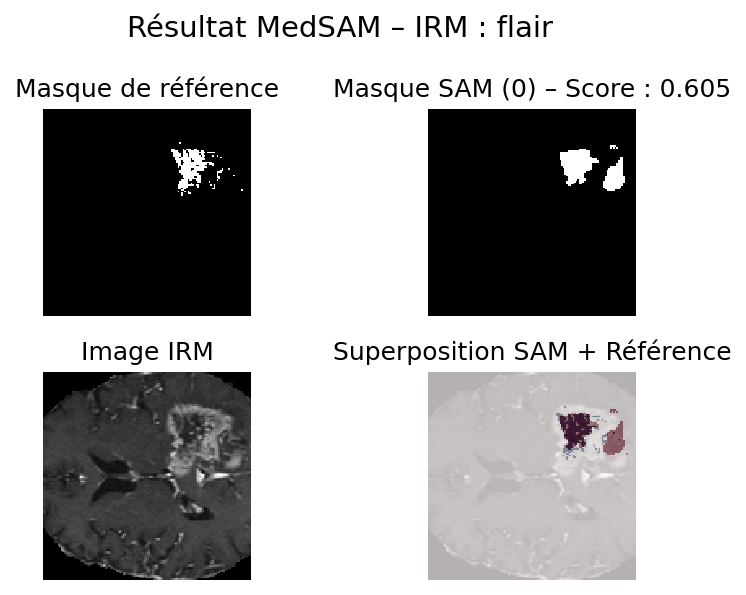

In [10]:
results["flair"][5].plot_masks(modality="flair")

medsam2_clinic/
  app/
    main.py          # API FastAPI
    routes.py        # endpoints
    models.py        # chargement modèle
    utils_io.py      # DICOM/NIfTI <-> numpy
    inference.py     # fonction run_inference(...)
  weights/
    medsam2_ckpt.pth
  tests/
  requirements.txt

In [ ]:
# app/main.py
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
import numpy as np
import cv2
from .models import model, device
from .inference import run_inference   # à écrire

app = FastAPI(title="MedSAM2 Clinical API")

@app.post("/segment")
async def segment_image(file: UploadFile = File(...)):
    # 1. lire l’image envoyée (ex : PNG)
    contents = await file.read()
    nparr = np.frombuffer(contents, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

    # 2. inference
    mask = run_inference(model, device, img)

    # 3. retourner le masque (par ex. encodé en PNG base64 ou en liste)
    mask_uint8 = (mask * 255).astype(np.uint8)
    _, buffer = cv2.imencode(".png", mask_uint8)
    mask_bytes = buffer.tobytes()

    # pour l’exemple, on renvoie juste la taille
    return JSONResponse({
        "height": int(mask.shape[0]),
        "width": int(mask.shape[1]),
        "message": "Segmentation ok"
    })


## Etapes:
* On vas 1 tester MedSam2 avec les poids des liasons IRM sur non image 128*128
* On vas continue utiliser MedSam mais avec des images non reseize
* Appliquer une propagation 3D intéligente
* prendre 100 images leur ouvrire et prendre donne pour chaque image pour slides calculer la tumeur les la tumeur et save
* On vas predire 5 mask pour 5 slide:
    * midle,  midle - 10 ,  milde + 10 , midle + 20, midel + 30
    * Sin on'a 3 mask donc le dice est est > à 70 on s'arrete 
    * si non on predict tout et on prend les 3 Mask avec le meilleur score
* On' applique le percentille sur les region predicte pour avoir un seuil min et max pour la propagation
* On calcul est metrique ( Vollume true - Volume predict) et les dice + IOU sur 10 coupes au hazzard
*  les algos de region growing 3D ou propagation par atlas local.

def adaptive_threshold(diff):
    t_min = np.percentile(diff, 20)
    t_max = np.percentile(diff, 80)
    return t_min, t_max


In [ ]:
def intensity_range(slice_ref, mask_ref, p_min=10, p_max=90):
    tumor_pixels = slice_ref[mask_ref > 0]
    return (
        np.percentile(tumor_pixels, p_min),
        np.percentile(tumor_pixels, p_max)
    )

from scipy.ndimage import binary_dilation

def propagate(slice_curr, prev_mask, I_min, I_max, dil_iter=2):
    appearance = (slice_curr > I_min) & (slice_curr < I_max)
    search_area = binary_dilation(prev_mask, iterations=dil_iter)
    return appearance & search_area

#La fenêtre s’adapte à la taille de la tumeur
radius = int(np.sqrt(np.sum(prev_mask)))
search_area = binary_dilation(prev_mask, iterations=radius//50 + 1)

In [ ]:
p_min = 10
p_max = 90
K = 2
tau = tau = 0.1 * np.sum(mask_ref) #10 % de la surface initiale
dilation = 1–2
lambda = 0.1


K = ...
tau = ...
lambda_update = ...

for direction in ["forward", "backward"]:
    for z in range_loop:
        candidate = (volume[:, :, z] > I_min) & (volume[:, :, z] < I_max)

        search_area = np.zeros_like(prev_mask)
        for k in range(1, K+1):
            search_area |= binary_dilation(mask_3d[:, :, z-k], iterations=1)

        mask_3d[:, :, z] = candidate & search_area

        if mask_3d[:, :, z].sum() < tau:
            mask_3d[:, :, z] = medsam_predict(volume[:, :, z])

        I_min, I_max = update_range(...)